In [1]:
# compile list of dysregulated genes/proteins targeted by CUL4B enriched regulator from IPA analysis
## network is generated using Cytoscape
## FIG 1E
import pandas as pd
from itertools import chain, combinations
import matplotlib.colors as c
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt


In [2]:
file_d={}
file_d['CUL4B'] = pd.ExcelFile('../results/IPA_downstream_analysis/regulator_pathways/CUL4B_REGULATOR_PATHWAYS.xlsx')

In [3]:
d={k:set() for k in file_d.keys()}
for k in d.keys():
    #print(k)
    for sheet in file_d[k].sheet_names:
        df = pd.read_excel(file_d[k], sheet_name=sheet, index_col=0)
        #print(len(set(df['GENE'])))
        #print(len(d[k].union(set(df['GENE']))))
        d[k] = d[k].union(set(df['GENE']))

In [4]:
network=pd.DataFrame(columns=['source', 'target'])
for key,value in d.items():
    for v in value:
         network = network.append({'source':key,'target':v}, ignore_index=True)

In [5]:
network.to_csv('../../results/IPA_downstream_analysis/cytoscape/cul4b_network.csv', index=False)

In [6]:
import pandas as pd

In [7]:
file_d={}
file_d['AREG'] = pd.ExcelFile('../results/IPA_downstream_analysis/regulator_pathways/AREG_REGULATOR_PATHWAYS.xlsx')
file_d['ATM'] = pd.ExcelFile('../results/IPA_downstream_analysis/regulator_pathways/ATM_REGULATOR_PATHWAYS.xlsx')
file_d['CUL4B'] = pd.ExcelFile('../results/IPA_downstream_analysis/regulator_pathways/CUL4B_REGULATOR_PATHWAYS.xlsx')
file_d['MYC'] = pd.ExcelFile('../results/IPA_downstream_analysis/regulator_pathways/MYC_REGULATOR_PATHWAYS.xlsx')
file_d['Pkg'] = pd.ExcelFile('../results/IPA_downstream_analysis/regulator_pathways/Pkg_REGULATOR_PATHWAYS.xlsx')
file_d['Rac'] = pd.ExcelFile('../results/IPA_downstream_analysis/regulator_pathways/Rac_REGULATOR_PATHWAYS.xlsx')
file_d['ROCK'] = pd.ExcelFile('../results/IPA_downstream_analysis/regulator_pathways/ROCK_REGULATOR_PATHWAYS.xlsx')

d={k:set() for k in file_d.keys()}
for k in d.keys():
    #print(k)
    for sheet in file_d[k].sheet_names:
        df = pd.read_excel(file_d[k], sheet_name=sheet, index_col=0)
        #print(len(set(df['GENE'])))
        #print(len(d[k].union(set(df['GENE']))))
        d[k] = d[k].union(set(df['GENE']))

In [8]:
master = pd.DataFrame(columns=['Dataset']+list(d.keys()), index=[l for k in set([i for j in d.values() for i in j]) for l in [k]*4])
master['Dataset']=['6HR_MRSA', '24HR_MRSA', 'PROT', 'PHOS']*len(set([i for j in d.values() for i in j]))

In [9]:
data_d = {'6HR_MRSA':{k:[] for k in file_d.keys()}, '24HR_MRSA':{k:[] for k in file_d.keys()}, \
          'PROT':{k:[] for k in file_d.keys()}, 'PHOS':{k:[] for k in file_d.keys()}}
for k in file_d.keys():
    for sheet in file_d[k].sheet_names:
        df = pd.read_excel(file_d[k], sheet_name=sheet, index_col=0)
        data_d['6HR_MRSA'][k]+=list(df.loc[df['DEG_6HR_MRSA_ADJPVAL']<=0.05].loc[abs(df['DEG_6HR_MRSA_LOG2FC'])>=0.585]['GENE'])
        data_d['24HR_MRSA'][k]+=list(df.loc[df['DEG_24HR_MRSA_ADJPVAL']<=0.05].loc[abs(df['DEG_24HR_MRSA_LOG2FC'])>=0.585]['GENE'])
        data_d['PROT'][k]+=list(df.loc[df['PROT_ADJPVAL']<=0.05]['GENE'])
        data_d['PHOS'][k]+=list(df.loc[df['PHOS_ADJPVAL']<=0.05]['GENE'])

In [10]:
AREG=[]
ATM=[]
CUL4B=[]
MYC=[]
Pkg=[]
Rac=[]
ROCK=[]
for i,j in zip(master.index,master['Dataset']):
    for reg in ['AREG','ATM','CUL4B','MYC','Pkg','Rac','ROCK']:
        if reg=='AREG':
            AREG.append(i in data_d[j][reg])
        elif reg=='ATM':
            ATM.append(i in data_d[j][reg])
        elif reg=='CUL4B':
            CUL4B.append(i in data_d[j][reg])
        elif reg=='MYC':
            MYC.append(i in data_d[j][reg])
        elif reg=='Pkg':
            Pkg.append(i in data_d[j][reg])
        elif reg=='Rac':
            Rac.append(i in data_d[j][reg])
        elif reg=='ROCK':
            ROCK.append(i in data_d[j][reg])
master['AREG']=AREG
master['ATM']=ATM
master['CUL4B']=CUL4B
master['MYC']=MYC
master['Pkg']=Pkg
master['Rac']=Rac
master['ROCK']=ROCK

In [11]:
regs=['AREG','ATM','CUL4B','MYC','Pkg','Rac','ROCK']
master=master.reset_index()
drop_indx = list(master.loc[master['ATM']==False].loc[master['AREG']==False].loc[master['CUL4B']==False].loc[master['MYC']==False].loc[master['Pkg']==False].loc[master['Rac']==False].loc[master['ROCK']==False].index)
master.drop(master.index[drop_indx], inplace=True)

In [13]:
cul4b_master = master[['index', 'Dataset', 'CUL4B']]
# cul4b_master

,index,Dataset,CUL4B
0,DTYMK,6HR_MRSA,False
2,DTYMK,PROT,False
4,B2M,6HR_MRSA,False
5,B2M,24HR_MRSA,False
6,B2M,PROT,False
...,...,...,...
2441,SPC25,24HR_MRSA,False
2442,SPC25,PROT,False
2444,FOSL1,6HR_MRSA,False
2445,FOSL1,24HR_MRSA,False


In [14]:
def all_subsets(ss):
    return chain(*map(lambda x: combinations(ss, x), range(0, len(ss)+1)))

subsets=[]
for subset in all_subsets(set(master['Dataset'])):
    subsets.append(subset)

cmap=plt.cm.get_cmap('turbo', len(subsets))
color_d={}
for i in range(len(subsets)):
    color_d[subsets[i]]=c.to_hex(cmap(i))
color_d

{(): '#30123b',
 ('6HR_MRSA',): '#4143a7',
 ('24HR_MRSA',): '#4771e9',
 ('PROT',): '#3e9bfe',
 ('PHOS',): '#22c5e2',
 ('6HR_MRSA', '24HR_MRSA'): '#1ae4b6',
 ('6HR_MRSA', 'PROT'): '#46f884',
 ('6HR_MRSA', 'PHOS'): '#88ff4e',
 ('24HR_MRSA', 'PROT'): '#b9f635',
 ('24HR_MRSA', 'PHOS'): '#e1dd37',
 ('PROT', 'PHOS'): '#faba39',
 ('6HR_MRSA', '24HR_MRSA', 'PROT'): '#fd8d27',
 ('6HR_MRSA', '24HR_MRSA', 'PHOS'): '#f05b12',
 ('6HR_MRSA', 'PROT', 'PHOS'): '#d63506',
 ('24HR_MRSA', 'PROT', 'PHOS'): '#af1801',
 ('6HR_MRSA', '24HR_MRSA', 'PROT', 'PHOS'): '#7a0403'}

In [15]:
nodes = list(network['target'])
node_colors = []
for node in nodes:
    pass_set = set(cul4b_master.loc[cul4b_master['index']==node].loc[cul4b_master['CUL4B']==True]['Dataset'])
    node_color=color_d[()]
    for k in color_d.keys():
        if len(set(k)-pass_set) == 0:
            node_color=color_d[k]
    node_colors.append(node_color)

In [16]:
node_attr = pd.DataFrame(columns=['target', 'color'])
node_attr['target']=nodes
node_attr['color']=node_colors

In [17]:
node_attr.to_csv('../results/IPA_downstream_analysis/cytoscape/cul4b_network_attr.csv', index=False)

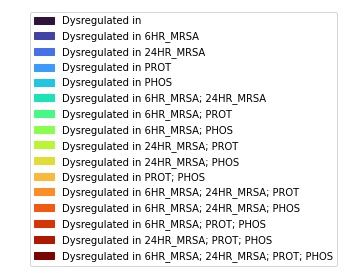

In [20]:


patches = []
for group, color in color_d.items():
    patches.append(mpatches.Patch(color=c.to_rgb(color), label='Dysregulated in {}'.format('; '.join(group))))
plt.legend(handles=patches)
plt.axis('off')
plt.savefig('../results/IPA_downstream_analysis/cytoscape/CUL4B_NET_LEGEND.pdf', bbox_inches='tight')
plt.show()